<a href="https://colab.research.google.com/github/Abeldb11/Ahadu/blob/main/JEPA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, TensorDataset

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Load Pre-trained ViT
model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
model = model.to(device)

# Strictly prevent gradient updates (Freeze)
for param in model.parameters():
    param.requires_grad = False

# Set to evaluation mode
model.eval()
print("ViT loaded and parameters frozen.")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:04<00:00, 72.8MB/s]


ViT loaded and parameters frozen.


In [ ]:
import torch
from torch import amp # Updated for the new API
from torchvision import models

# 1. Force Device Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if device.type == 'cpu':
    print("WARNING: You are still on CPU. Go to Runtime > Change runtime type!")

# 2. Load and Freeze model on the correct device
model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1).to(device)
for param in model.parameters():
    param.requires_grad = False
model.eval()

# 3. Updated Fast Extraction Function
def extract_features_fast(loader, model):
    all_features = []
    all_labels = []

    print(f"Starting extraction on {device}...")

    with torch.no_grad():
        # Updated autocast syntax to solve the warning
        # Use 'cuda' if available, otherwise 'cpu'
        device_type = 'cuda' if torch.cuda.is_available() else 'cpu'

        with amp.autocast(device_type=device_type):
            for i, (images, labels) in enumerate(loader):
                images = images.to(device, non_blocking=True)
                features = model(images)

                all_features.append(features.cpu())
                all_labels.append(labels)

                if (i + 1) % 10 == 0:
                    print(f"Batch {i+1}/{len(loader)} finished...")

    return torch.cat(all_features), torch.cat(all_labels)

# Run it!
# X_train, y_train = extract_features_fast(train_loader, model)

Using device: cuda


In [ ]:
import torch
from torch import amp
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader, Subset, TensorDataset

# 1. Force the GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == 'cpu':
    print("STOP! You are on CPU. Go to Runtime > Change runtime type to GPU!")

# 2. Load Pre-trained ViT and Freeze it
model = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1).to(device)
for param in model.parameters():
    param.requires_grad = False
model.eval()
print("Model loaded and frozen.")

Using device: cuda
Model loaded and frozen.


In [ ]:
# 1. Mandatory resize for ViT
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 2. Load Data and Subsample to 5,000 images for speed
full_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_dataset = Subset(full_train, torch.arange(5000))
train_loader = DataLoader(train_dataset, batch_size=128, num_workers=2, pin_memory=True)

# 3. Fast Extraction Function (fixes the warning and uses GPU)
def extract_features(loader, model):
    all_features, all_labels = [], []
    print(f"Extracting features on {device}...")
    with torch.no_grad():
        with amp.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
            for images, labels in loader:
                images = images.to(device, non_blocking=True)
                features = model(images)
                all_features.append(features.cpu())
                all_labels.append(labels)
    return torch.cat(all_features), torch.cat(all_labels)

X_train, y_train = extract_features(train_loader, model)

# Create a new, fast dataloader from the extracted features
cached_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
print("Extraction complete! Features cached.")

Extracting features on cuda...
Extraction complete! Features cached.


Training Linear Probe...
Probe training finished.
Generating t-SNE plot (this takes a few seconds)...


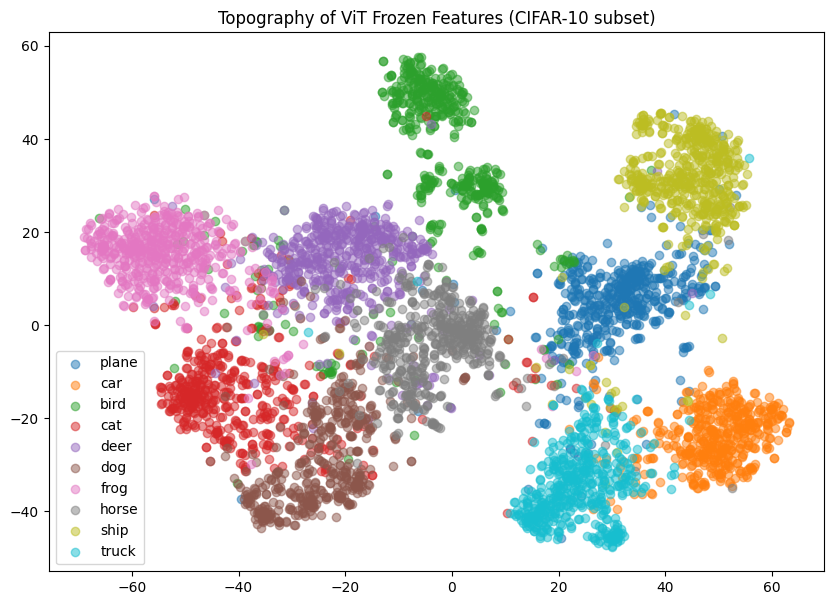

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. Build and Train the Linear Probe
# Ensure features are float32 and labels are long to avoid dtype mismatches
X_train_fix = X_train.to(torch.float32)
y_train_fix = y_train.to(torch.long)

# Update the loader with fixed types
cached_loader = DataLoader(TensorDataset(X_train_fix, y_train_fix), batch_size=64, shuffle=True)

probe = torch.nn.Linear(X_train_fix.shape[1], 10).to(device)
optimizer = torch.optim.Adam(probe.parameters(), lr=1e-3)
criterion = torch.nn.CrossEntropyLoss()

print("Training Linear Probe...")
for epoch in range(10):
    for feat, lab in cached_loader:
        feat, lab = feat.to(device), lab.to(device)
        optimizer.zero_grad()
        loss = criterion(probe(feat), lab)
        loss.backward()
        optimizer.step()
print("Probe training finished.")

# 2. Visualize Topography with t-SNE
print("Generating t-SNE plot (this takes a few seconds)...")
tsne = TSNE(n_components=2, random_state=42).fit_transform(X_train_fix.numpy())

plt.figure(figsize=(10, 7))
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
for i in range(10):
    mask = y_train_fix.numpy() == i
    plt.scatter(tsne[mask, 0], tsne[mask, 1], label=classes[i], alpha=0.5)

plt.legend()
plt.title("Topography of ViT Frozen Features (CIFAR-10 subset)")
plt.show()